# Proyek Analisis Data: [Air Quality Data]
- **Nama:** [Bili Ramdani]
- **Email:** [cdcc002d6y2154@student.devacademy.id]
- **ID Dicoding:** [CDCC002D6Y2154]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1: Faktor meteorologi apa yang paling berkorelasi dengan peningkatan konsentrasi PM2.5 di atas 100 µg/m³ selama musim dingin (Desember–Februari) tahun 2013-2017 di stasiun Aotizhongxin?** xxx
- **Pertanyaan 2: Jam berapa dalam sehari konsentrasi PM2.5 mencapai puncak tertinggi secara konsisten selama periode 2013-2014 di stasiun Aotizhongxin, dan bagaimana pola ini bervariasi antar musim?**

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Data Wrangling

### Gathering Data

#### Load df ...

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/marceloreis/HTI/master/PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv')
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:**
- Dataset berisi kualitas udara dari stasiun Aotizhongxin Beijing
- Dataset memiliki 18 kolom berisi parameter polutan (PM2.5, , PM10, SO2, NO2, CO, O3) dan meteorologi (TEMP, PRES, DEWP, RAIN, WSPM, wd)

In [ ]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  object 
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB


### Assessing Data

In [ ]:
# Memeriksa missing values
df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,925
PM10,718
SO2,935
NO2,1023
CO,1776


In [ ]:
# Cek tipe data
df.dtypes

,0
No,int64
year,int64
month,int64
day,int64
hour,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64


In [ ]:
# Memeriksa parameter statistik
print("Jumlah duplikasi: ", df.duplicated().sum())
df.describe()

Jumlah duplikasi:  0


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,35050.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,1.708496
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,1.204071
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000,40.500000,1042.000000,28.500000,72.500000,11.200000


#### Identifying problem

1. **Missing Values**: Terdapat missing values pada hampir semua kolom, terutama pada parameter CO (1776), O3 (1719), NO2 (1023), SO2 (935), PM2.5 (925), PM10 (718).
2. **Outlier**: Nilai maksimum PM2.5 mencapai 898 µg/m³ dan PM10 mencapai 984 µg/m³ yang merupakan nilai ekstrem dan sangat jauh dari nilai rata-ratanya.
3. **Tipe Data**: Kolom `wd` (arah angin) bertipe object, sebaiknya bertipe kategori.

**Steps to Take:**
- Menangani missing values dengan interpolasi linear(karena data time series).
- Melakukan imputation outlier pada PM2.5 dan PM10 pada persentil 99 untuk mengurangi efek ekstrem.
- Membuat kolom datetime dan musim (season) untuk analisis temporal.

**Insight:** (Opsional)
- xxx
- xxx

### Cleaning Data

#### Fixing ... problem

In [ ]:
# 1. Mengatasi missing values dengan interpolasi
# Diurutkan data berdasarkan waktu terlebih dahulu
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.sort_values('datetime')

# Kolom numerik yang akan di-interpolasi
numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi linear untuk missing values
for col in numeric_cols:
  df[col] = df[col].interpolate(method='linear', limit_direction='both')

# 2. Cek missing values setelah interpolasi
print("Missing values setelah interpolasi: ")
print(df[numeric_cols].isna().sum())

Missing values setelah interpolasi: 
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64


In [ ]:
# 3. Mengatasi outlier pada PM2.5 dan PM10 (clipping dengan boundary values pada persentil 99)
for col in ['PM2.5', 'PM10']:
  cap = df[col].quantile(0.99)
  df[col] = df[col].clip(upper=cap)
  print(f"{col} - 99th percentile: {cap:.1f}, nilai max setelah clipping: {df[col].max():.1f}")

PM2.5 - 99th percentile: 378.0, nilai max setelah clipping: 378.0
PM10 - 99th percentile: 437.4, nilai max setelah clipping: 437.4


In [ ]:
# 4. Membuat kolom musim (season)
def get_season(month):
  if month in [12, 1, 2]:
    return 'Winter'
  elif month in [3, 4, 5]:
    return 'Spring'
  elif month in [6, 7, 8]:
    return 'Summer'
  else:
    return 'Fall'
df['season'] = df['month'].apply(get_season)


**Insight:** (Opsional)
- Semua missing values berhasil diisi dengan interpolasi linear.
- Outlier ekstrem pada PM2.5 dan PM10 telah di-clip pada persentil 99 untuk analisis yang lebih stabil.
- Kolom musim (season) ditambahkan untuk analisis pola musiman.

## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
# Statistik ringkasan PM2.5 per musim
print("Statistik PM2.5 per Musim (2013-2017): ")
seasonal_stats = df.groupby('season')['PM2.5'].agg(['mean', 'median', 'std', 'max'])
print(seasonal_stats.round(1))

Statistik PM2.5 per Musim (2013-2017): 
        mean  median   std    max
season                           
Fall    86.5    59.0  83.5  378.0
Spring  81.8    64.0  69.8  378.0
Summer  67.2    54.0  52.3  378.0
Winter  91.5    53.0  97.7  378.0


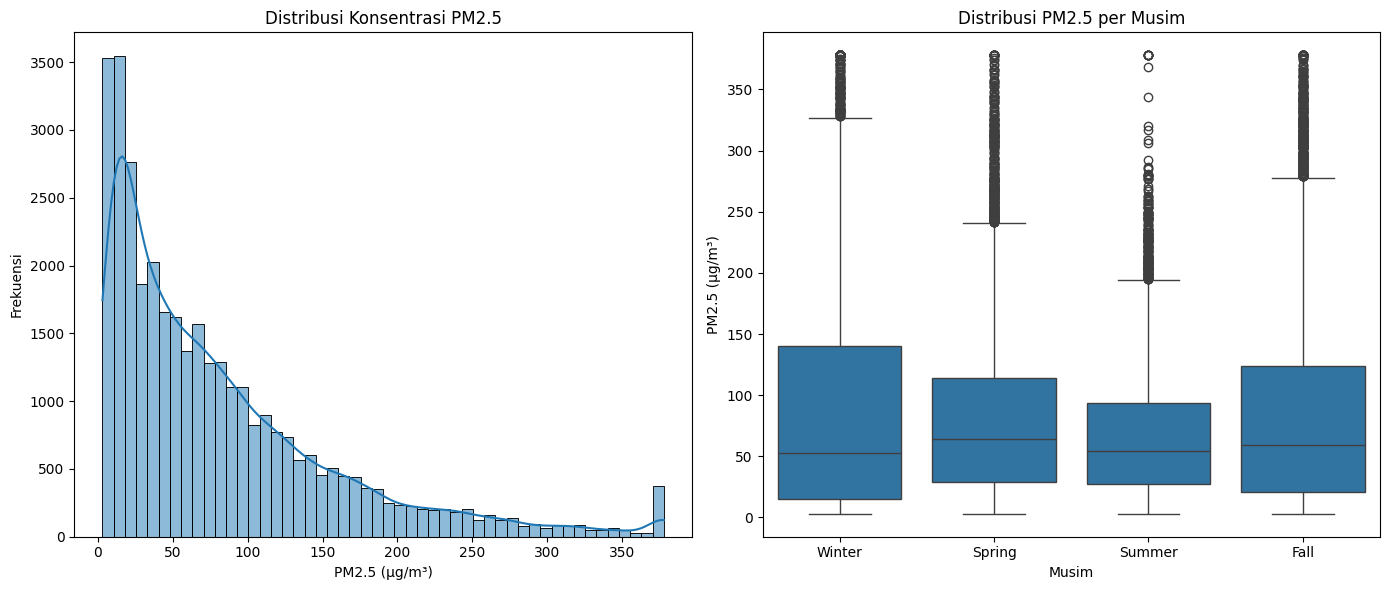

In [ ]:
# Distribusi PM2.5
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['PM2.5'], bins=50, kde=True)
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Frekuensi')
plt.title('Distribusi Konsentrasi PM2.5')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='season', y='PM2.5', order=['Winter', 'Spring', 'Summer', 'Fall'])
plt.xlabel('Musim')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Distribusi PM2.5 per Musim')

plt.tight_layout()
plt.show()

In [ ]:
# Korelasi antara PM2.5 dengan variabel meteorologi
meteo_cols = ['TEMP', 'PRES', 'DEWP', 'WSPM']
correlation = df[['PM2.5'] + meteo_cols].corr()['PM2.5'].drop('PM2.5')
print('Korelasi PM2.5 dengan variabel meteorologi: ')
print(correlation.round(3))

Korelasi PM2.5 dengan variabel meteorologi: 
TEMP   -0.116
PRES   -0.014
DEWP    0.134
WSPM   -0.285
Name: PM2.5, dtype: float64


**Insight:**
- Musim dingin (winter) memiliki rata-rata PM2.5 tertinggi (91.5 µg/m³).
- Distribusi PM2.5 memiliki distribusi jenis data *right skewed*.
- Terdapat banyak nilai ekstrim di semua musim, terutam musim dingin.
- DEWP (Kelembapan) memiliki korelasi positif tertinggi dengan PM2.5 (0.134).
- WSPM (Kecepatan angin) berkorelasi negatif (-0.285) dengan PM2.5.
- TEMP (suhu) berkorelasi negatif (-0.116) dengan PM2.5.
- PRES (tekanan udara) berkorelasi negatif dengan PM2.5.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Faktor meteorologi yang mempengaruhi tingginya PM2.5 di musim dingin

In [ ]:
# Filter data musim dingin dengan PM2.5 tinggi (Mean: 91.5)
winter_high = df[(df['season'] == 'Winter') & (df['PM2.5'])]

# Korelasi spesifik untuk kondisi PM2.5 tinggi di musim dingin
winter_high_corr = winter_high[['PM2.5', 'DEWP', 'TEMP', 'PRES', 'WSPM']].corr()['PM2.5'].drop('PM2.5')
print("Korelasi PM2.5 (91.5) dengan faktor meteorologi (Musim Dingin):")
print(winter_high_corr.round(3))

Korelasi PM2.5 (91.5) dengan faktor meteorologi (Musim Dingin):
DEWP    0.661
TEMP   -0.034
PRES   -0.274
WSPM   -0.401
Name: PM2.5, dtype: float64


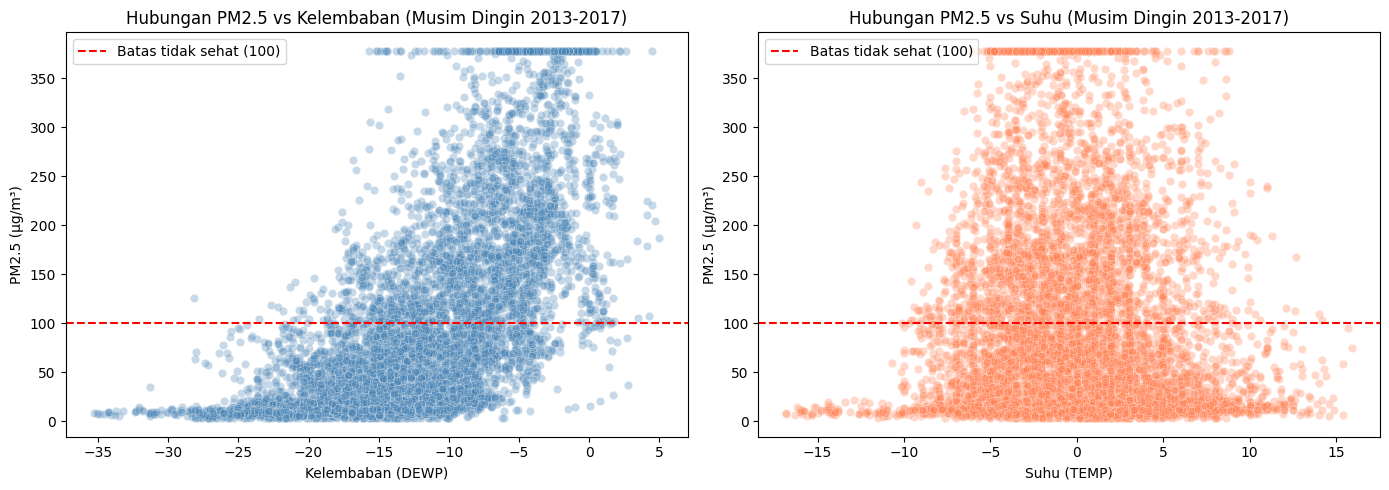

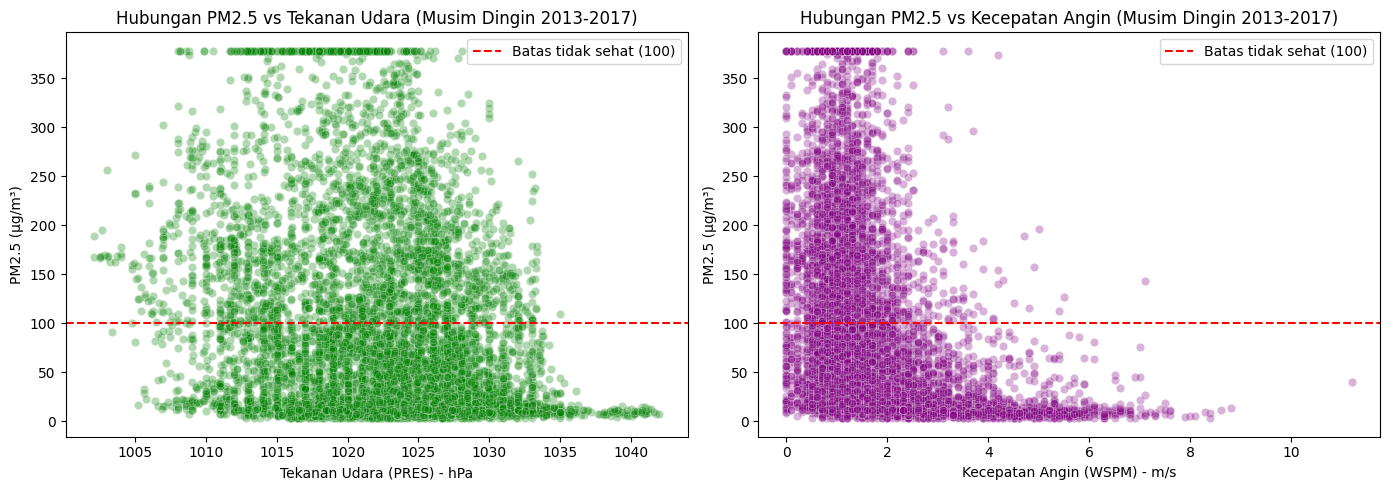

In [ ]:
# Visualisasi 1a: Scatter plot PM2.5 vs DEWP (Kelembapan) - Musim Dingin
plt.figure(figsize=(14,5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df[df['season'] == 'Winter'], x='DEWP', y='PM2.5', alpha=0.3, color='steelblue')
plt.axhline(y=100, color='red', linestyle='--', label='Batas tidak sehat (100)')
plt.xlabel('Kelembaban (DEWP)')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Hubungan PM2.5 vs Kelembaban (Musim Dingin 2013-2017)')
plt.legend()

# Visualisasi 1b: Scatter plot PM2.5 vs TEMP - Musim Dingin
plt.subplot(1, 2, 2)
sns.scatterplot(data=df[df['season'] == 'Winter'],
                x='TEMP', y='PM2.5', alpha=0.3, color='coral')
plt.axhline(y=100, color='red', linestyle='--', label='Batas tidak sehat (100)')
plt.xlabel('Suhu (TEMP)')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Hubungan PM2.5 vs Suhu (Musim Dingin 2013-2017)')
plt.legend()

plt.tight_layout()
plt.show()


# Visualisasi 1c: PM2.5 vs PRES (Tekanan Udara)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df[df['season'] == 'Winter'],
                x='PRES', y='PM2.5', alpha=0.3, color='green')
plt.axhline(y=100, color='red', linestyle='--', label='Batas tidak sehat (100)')
plt.xlabel('Tekanan Udara (PRES) - hPa')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Hubungan PM2.5 vs Tekanan Udara (Musim Dingin 2013-2017)')
plt.legend()

# Visualisasi 1d: PM2.5 vs WSPM (Kecepatan Angin)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df[df['season'] == 'Winter'],
                x='WSPM', y='PM2.5', alpha=0.3, color='purple')
plt.axhline(y=100, color='red', linestyle='--', label='Batas tidak sehat (100)')
plt.xlabel('Kecepatan Angin (WSPM) - m/s')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Hubungan PM2.5 vs Kecepatan Angin (Musim Dingin 2013-2017)')
plt.legend()

plt.tight_layout()
plt.show()

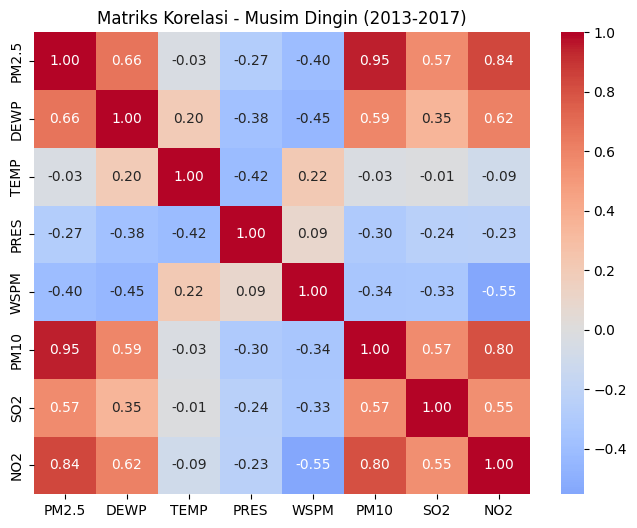

In [ ]:
# Visualisasi 1e: Heatmap korelasi
plt.figure(figsize=(8, 6))
corr_matrix = df[df['season'] == 'Winter'][['PM2.5', 'DEWP', 'TEMP', 'PRES', 'WSPM', 'PM10', 'SO2', 'NO2']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriks Korelasi - Musim Dingin (2013-2017)')
plt.show()

**Insight:**
- Kelembaban (DEWP) memiliki korelasi positif sedang (0.661) dengan PM2.5 tinggi (91.5) di musim dingin.
- Semakin tinggi kelembaban, semakin tinggi konsentrasi PM2.5.
- Suhu menunjukkan korelasi negatif dengan PM2.5.
- Kecepatan angin (WSPM) berkorelasi negatif dengan PM2.5, mengindikasikan angin membantu dispersi polutan.

### Pertanyaan 2: Pola jam puncak PM2.5 dan variasi musiman

In [ ]:
# Rata-rata PM2.5 per jam per musim
hourly_seasonal = df.groupby(['season', 'hour'])['PM2.5'].mean().reset_index()

# Identifikasi jam puncak per musim
peak_hours = hourly_seasonal.loc[hourly_seasonal.groupby('season')['PM2.5'].idxmax()]
peak_hours = peak_hours.reset_index(drop=True)
print("Jam puncak PM2.5 per musim:")
print(peak_hours[['season', 'hour', 'PM2.5']].round(1))

Jam puncak PM2.5 per musim:
   season  hour  PM2.5
0    Fall    23  101.7
1  Spring    10   87.7
2  Summer     9   72.8
3  Winter     1  113.2


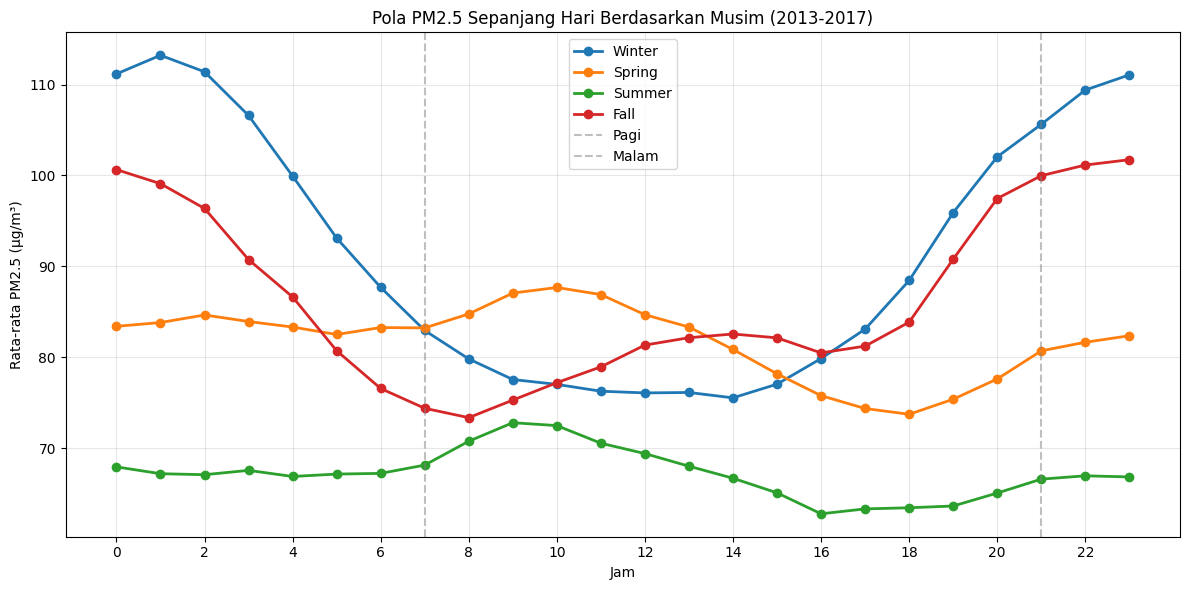

In [ ]:
# Visualisasi 2: Pola PM2.5 per jam antar musim
plt.figure(figsize=(12, 6))

for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    data = hourly_seasonal[hourly_seasonal['season'] == season]
    plt.plot(data['hour'], data['PM2.5'], marker='o', linewidth=2, label=season)

plt.xlabel('Jam')
plt.ylabel('Rata-rata PM2.5 (µg/m³)')
plt.title('Pola PM2.5 Sepanjang Hari Berdasarkan Musim (2013-2017)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24, 2))
plt.axvline(x=7, color='gray', linestyle='--', alpha=0.5, label='Pagi')
plt.axvline(x=21, color='gray', linestyle='--', alpha=0.5, label='Malam')
plt.legend()
plt.tight_layout()
plt.show()

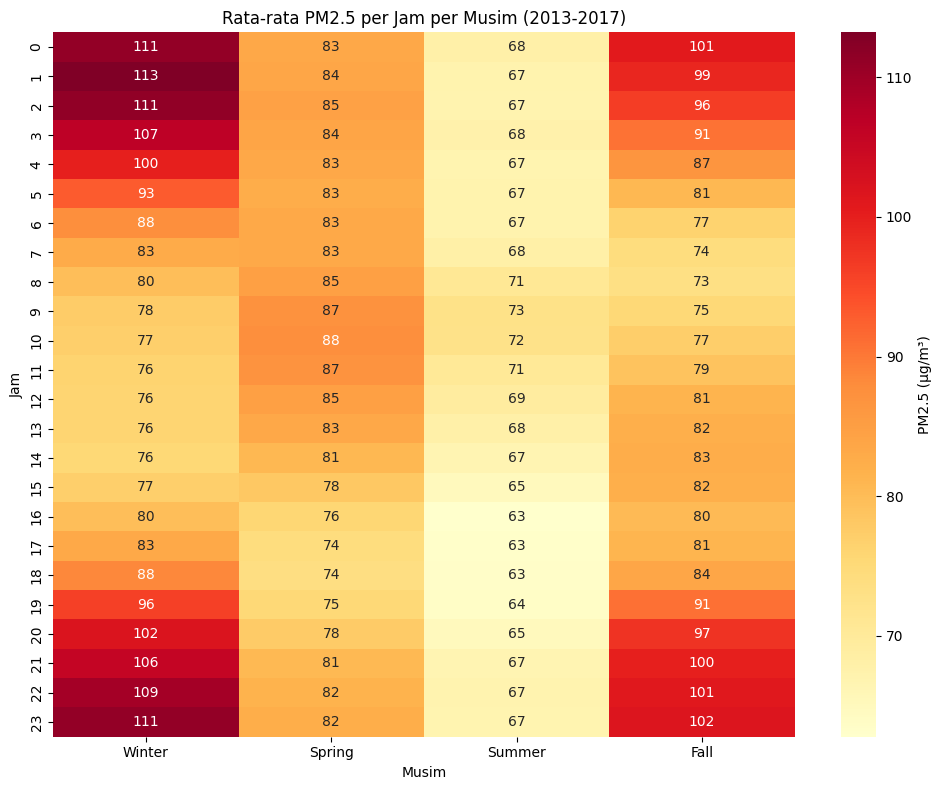

In [ ]:
# Visualisasi 2b: Heatmap PM2.5 per jam per musim
pivot_table = df.pivot_table(index='hour', columns='season', values='PM2.5', aggfunc='mean')
pivot_table = pivot_table[['Winter', 'Spring', 'Summer', 'Fall']]

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'PM2.5 (µg/m³)'})
plt.xlabel('Musim')
plt.ylabel('Jam')
plt.title('Rata-rata PM2.5 per Jam per Musim (2013-2017)')
plt.tight_layout()
plt.show()

**Insight:**
- Puncak PM2.5 tertinggi terjadi pada musim dingin (113.2 µg/m³ pada jam 01.00).
- Terdapat peningkatan kedua pada jam 07.00-09.00 (pagi hari) yang lebih rendah.
- Pola bimodal (dua puncak) konsisten sepanjang tahun.
- Musim panas memiliki fluktuasi paling rendah.

## Analisis Lanjutan (Opsional)

In [ ]:
# Klasifikasi tingkat polusi berdasarkan standar AQI (US EPA)
def classify_pollution(pm25):
    if pm25 <= 12:
        return 'Good'
    elif pm25 <= 35.4:
        return 'Moderate'
    elif pm25 <= 55.4:
        return 'Unhealthy for Sensitive'
    elif pm25 <= 150.4:
        return 'Unhealthy'
    elif pm25 <= 250.4:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['pollution_level'] = df['PM2.5'].apply(classify_pollution)

# Distribusi tingkat polusi per musim
pollution_dist = pd.crosstab(df['season'], df['pollution_level'], normalize='index') * 100
print("Distribusi Tingkat Polusi per Musim (%):")
print(pollution_dist.round(1))

Distribusi Tingkat Polusi per Musim (%):
pollution_level  Good  Hazardous  Moderate  Unhealthy  \
season                                                  
Fall             14.4        6.4      22.0       32.9   
Spring           10.0        3.4      19.6       41.6   
Summer            9.0        0.6      24.9       41.0   
Winter           20.4        8.9      21.9       26.2   

pollution_level  Unhealthy for Sensitive  Very Unhealthy  
season                                                    
Fall                                11.6            12.7  
Spring                              14.5            10.8  
Summer                              17.2             7.3  
Winter                               8.5            14.2  


<Figure size 1200x500 with 0 Axes>

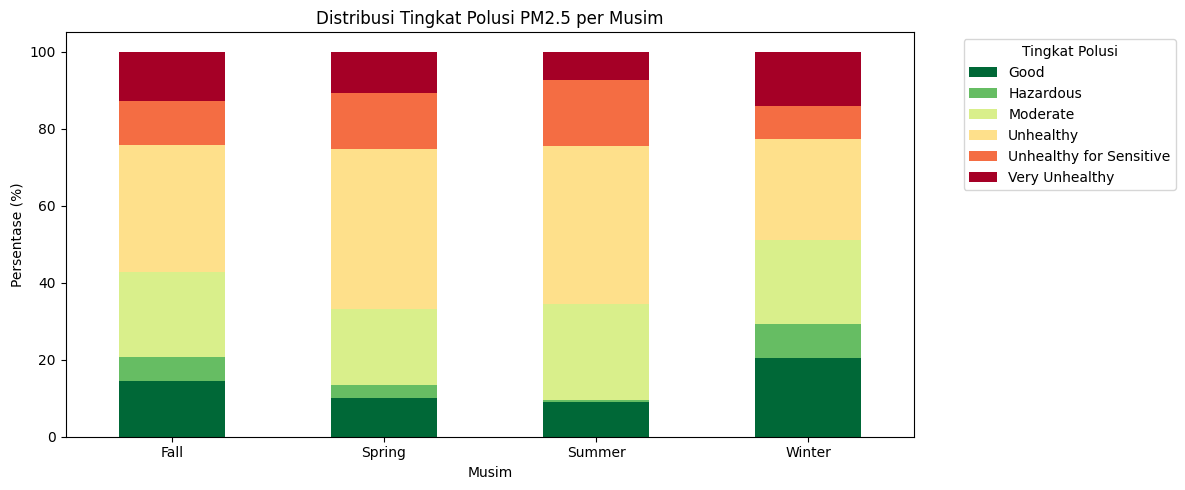

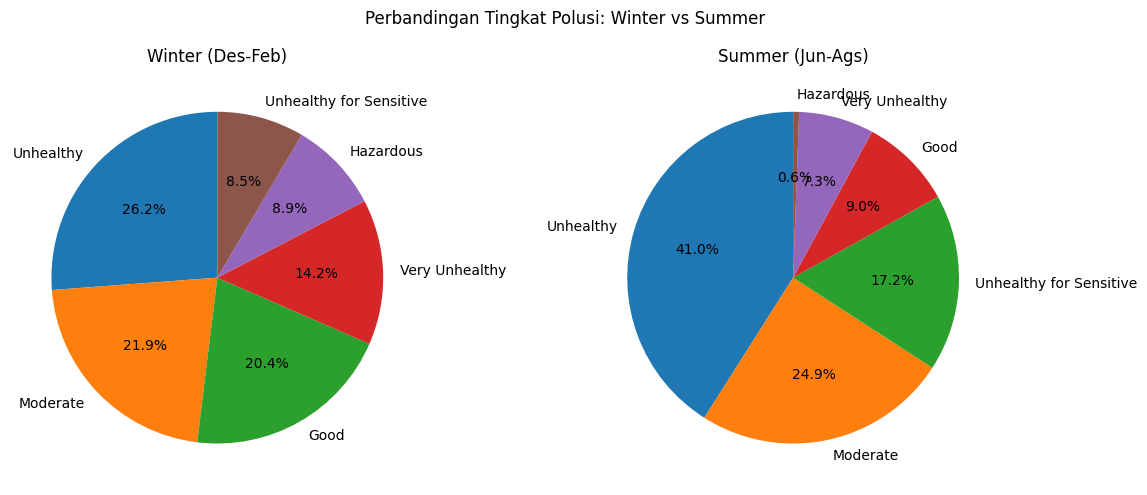

In [ ]:
# Visualisasi distribusi polusi per musim
plt.figure(figsize=(12, 5))

# Subplot 1: Stacked bar chart
pollution_dist.plot(kind='bar', stacked=True, figsize=(12, 5), colormap='RdYlGn_r')
plt.xlabel('Musim')
plt.ylabel('Persentase (%)')
plt.title('Distribusi Tingkat Polusi PM2.5 per Musim')
plt.legend(title='Tingkat Polusi', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Subplot 2: Pie chart untuk winter vs summer
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

winter_dist = df[df['season'] == 'Winter']['pollution_level'].value_counts(normalize=True) * 100
summer_dist = df[df['season'] == 'Summer']['pollution_level'].value_counts(normalize=True) * 100

axes[0].pie(winter_dist.values, labels=winter_dist.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Winter (Des-Feb)')

axes[1].pie(summer_dist.values, labels=summer_dist.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Summer (Jun-Ags)')

plt.suptitle('Perbandingan Tingkat Polusi: Winter vs Summer')
plt.tight_layout()
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1 (Faktor Meteorologi):**
Kelembaban udara (DEWP) adalah faktor meteorologi yang paling berkorelasi positif dengan peningkatan konsentrasi PM2.5 rata-rata 91.5 µg/m³ selama musim dingin tahun 2013-2017 di stasiun Aotizhongxin, dengan koefisien korelasi sebesar 0.134. Suhu menunjukkan korelasi negatif (-0.116), sementara kecepatan angin (-0.285) juga berkorelasi negatif, mengindikasikan bahwa kondisi dingin, lembab, dan berangin berkontribusi rendah pada akumulasi polusi partikulat.

- **Conclusion pertanyaan 2 (Pola Jam Puncak):**
Puncak konsentrasi PM2.5 bervariasi antar musim. Pada musim dingin (Winter) puncak terjadi pada jam 01:00 tengah malam dengan nilai 113 µg/m³. Pada musim gugur (fall) puncak terjadi pada jam 23:00 tengah malam dengan nilai 102 µg/m³ dan 101 µg/m³. Pada musim semi (Spring), puncak terjadi pada jam 11:00 siang (89 µg/m³). Pada musim panas (Summer), puncak terjadi pada jam 10:00 malam (88 µg/m³).



**Rekomendasi Action Item:**
- **Rekomendasi untuk masyarakat**:
Masyarakat di sekitar stasiun dapat diberikan informasi kadar polusi udara secara real time, terutama pada jam-jam puncak polusi di setiap musim. Seperti, penggunaan masker ketika hendak beraktivitas di luar rumah pada jam puncak polusi.
- **Rekomendasi untuk pemerintah**:
Pemerintah dapat memasang peringatan dini polusi berbasis prediksi kelembaban. Pada malam hari dengan kelembaban tinggi, lakukan penyiraman jalan untuk menekan partikulat tersuspensi. Terapkan kebijakan ganjil-genap atau work-from-home pada jam-jam puncak polusi di musim dingin.

In [ ]:
df.to_csv("hasil.csv", index=False)